# 03 — Modelos

Se entrena y evalúa un **baseline pre-entrenado** (TextBlob) y **dos modelos propios**:

| | vectorización | modelo |
|---|---|---|
| Modelo 1 | Bag of Words | Naive Bayes |
| Modelo 2 | TF-IDF | Reg. Logística |

Todos se evalúan **en train y en test** para poder detectar sobreajuste.

**Entrada:** los parquet de la notebook 02. **Salida:** vectorizadores, modelos y métricas.

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (9, 5)

PROCESSED = Path("..") / "data" / "processed"
MODELS = Path("..") / "models"
MODELS.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(PROCESSED / "train_clean.parquet")
df_test = pd.read_parquet(PROCESSED / "test_clean.parquet")

X_train = df["text_clean"]
y_train = df["polarity"].map({0: -1, 4: 1})

df_test_bin = df_test[df_test["polarity"] != 2]
X_test_bin = df_test_bin["text_clean"]
y_test_bin = df_test_bin["polarity"].map({0: -1, 4: 1})
X_test_full = df_test["text_clean"]

print(f"Train: {len(X_train):,} tweets")
print(f"Test binario (pos/neg): {len(X_test_bin)} tweets")
print(f"Test completo (incluye neutral): {len(X_test_full)} tweets")

Train: 1,596,246 tweets
Test binario (pos/neg): 359 tweets
Test completo (incluye neutral): 498 tweets


## 4. Baseline: modelo pre-entrenado (TextBlob)

**Baseline pedido por la consigna:** ¿qué tan bien predice un modelo genérico pre-entrenado, que **nunca vio un tweet de este dataset**?

TextBlob funciona con un **léxico**: una lista de palabras con polaridad asignada a mano.

In [2]:
def textblob_pred(texto, umbral=0.05):
    polaridad = TextBlob(texto).sentiment.polarity
    if polaridad > umbral:
        return 1
    elif polaridad < -umbral:
        return -1
    return 0


t0 = time.time()
pred_textblob = X_test_bin.apply(textblob_pred)
print(f"TextBlob sobre {len(X_test_bin)} tweets: {time.time()-t0:.1f}s")

print(classification_report(y_test_bin, pred_textblob, zero_division=0))
acc_textblob = accuracy_score(y_test_bin, pred_textblob)
f1_textblob = f1_score(y_test_bin, pred_textblob, average="macro")


TextBlob sobre 359 tweets: 0.0s
              precision    recall  f1-score   support

          -1       0.87      0.42      0.56       177
           0       0.00      0.00      0.00         0
           1       0.72      0.76      0.74       182

    accuracy                           0.59       359
   macro avg       0.53      0.39      0.43       359
weighted avg       0.79      0.59      0.65       359



In [3]:
# ¿La comparacion es justa? Nuestra funcion usa umbral=0.05, y eso hace que TextBlob
# prediga "neutral" — una clase que el test binario no tiene, o sea, errada de entrada.
# Verificamos si esa decision es la que lo hunde, probando otros umbrales.

print("De los 177 negativos REALES, TextBlob predice:")
print(pred_textblob[y_test_bin == -1].value_counts().sort_index()
      .rename({-1: "negativo (acierta)", 0: "neutral (falla)", 1: "positivo (falla)"}).to_string())

print("\nSensibilidad al umbral:")
for u in [0.0, 0.05, 0.1, 0.2]:
    p = X_test_bin.apply(lambda t: textblob_pred(t, umbral=u))
    print(f"  umbral={u:<5} accuracy={accuracy_score(y_test_bin, p):.4f}  "
          f"F1 macro={f1_score(y_test_bin, p, average='macro'):.4f}  "
          f"neutrales={(p == 0).sum():>3}")

De los 177 negativos REALES, TextBlob predice:
text_clean
negativo (acierta)    74
neutral (falla)       49
positivo (falla)      54

Sensibilidad al umbral:
  umbral=0.0   accuracy=0.5989  F1 macro=0.4370  neutrales= 75
  umbral=0.05  accuracy=0.5905  F1 macro=0.4343  neutrales= 82
  umbral=0.1   accuracy=0.5599  F1 macro=0.4235  neutrales=100
  umbral=0.2   accuracy=0.4708  F1 macro=0.3828  neutrales=149


In [4]:
# ¿Por que falla TextBlob? Miramos la POLARIDAD CRUDA que asigna, antes del umbral.
# La escala va de -1 (maximo negativo) a +1 (maximo positivo); 0 = neutral.
# Para clasificar bien, a un tweet negativo le alcanza con recibir cualquier valor < 0.
polaridades = X_test_bin.apply(lambda t: TextBlob(t).sentiment.polarity)

resumen = polaridades.groupby(y_test_bin.map({-1: "REAL negativo", 1: "REAL positivo"})).agg(["mean", "median"])
print("Polaridad que asigna TextBlob, segun la clase REAL:")
print(resumen.round(3).to_string())

# ¿Le acierta al menos al SIGNO?
print("\n¿Acierta el signo?")
for clase, nombre in [(-1, "negativos"), (1, "positivos")]:
    p = polaridades[y_test_bin == clase]
    bien = (p < 0).sum() if clase == -1 else (p > 0).sum()
    mal  = (p > 0).sum() if clase == -1 else (p < 0).sum()
    cero = (p == 0).sum()
    print(f"  {nombre:>10}: signo correcto {bien:>3} ({bien/len(p)*100:>4.1f}%) | "
          f"signo INVERTIDO {mal:>3} ({mal/len(p)*100:>4.1f}%) | sin señal (0.0) {cero:>3} ({cero/len(p)*100:>4.1f}%)")

# ¿El lexico esta sesgado hacia lo positivo? Lo probamos con palabras sueltas.
print("\n¿Como puntua el lexico las palabras que SI conoce?")
print("  positivas:", {w: TextBlob(w).sentiment.polarity for w in ["good", "love", "great", "happy"]})
print("  negativas:", {w: TextBlob(w).sentiment.polarity for w in ["bad", "sad", "terrible", "awful"]})
print("  -> El lexico es SIMETRICO: good=+0.70 y bad=-0.70. No hay sesgo positivo.")

print("\n¿Y las palabras con las que la gente realmente se queja en Twitter?")
print("  ", {w: TextBlob(w).sentiment.polarity for w in ["aching", "ponzi", "cant"]})
print("  -> Valen 0.00: no estan en el lexico. Ese es el verdadero problema.")

print("\n  Ejemplos de NEGATIVOS que TextBlob no puede leer (polaridad 0.0):")
for t in X_test_bin[(polaridades == 0.0) & (y_test_bin == -1)].head(3):
    print(f"    - {t[:66]!r}")

Polaridad que asigna TextBlob, segun la clase REAL:
                mean  median
polarity                    
REAL negativo -0.058   0.000
REAL positivo  0.335   0.372

¿Acierta el signo?
   negativos: signo correcto  77 (43.5%) | signo INVERTIDO  57 (32.2%) | sin señal (0.0)  43 (24.3%)
   positivos: signo correcto 138 (75.8%) | signo INVERTIDO  12 ( 6.6%) | sin señal (0.0)  32 (17.6%)

¿Como puntua el lexico las palabras que SI conoce?
  positivas: {'good': 0.7, 'love': 0.5, 'great': 0.8, 'happy': 0.8}
  negativas: {'bad': -0.6999999999999998, 'sad': -0.5, 'terrible': -1.0, 'awful': -1.0}
  -> El lexico es SIMETRICO: good=+0.70 y bad=-0.70. No hay sesgo positivo.

¿Y las palabras con las que la gente realmente se queja en Twitter?
   {'aching': 0.0, 'ponzi': 0.0, 'cant': 0.0}
  -> Valen 0.00: no estan en el lexico. Ese es el verdadero problema.

  Ejemplos de NEGATIVOS que TextBlob no puede leer (polaridad 0.0):
    - "lebron is a beast but i'm still cheering the a til the end"
    -

**Conclusión — TextBlob: 0.59 accuracy / 0.43 F1**

Contra un azar de 0.50, **apenas le gana a una moneda**. Es el piso a superar.

**Es casi ciego a lo negativo:**

| clase real | polaridad mediana | acierta el signo |
|---|---|---|
| negativo | **0.000** | 43% |
| positivo | +0.372 | 76% |

**El culpable NO es el léxico — es simétrico:** `good`=+0.70, `bad`=**−0.70**.

**El culpable es el lenguaje:** nadie tuitea *"bad"*. La gente se queja con `aching`, `ponzi`, `cant` → **valen 0.00, no están en la lista**.

**¿Comparación injusta?** Se midió: con el mejor umbral llega a 0.5989. **El umbral no lo salva** — es problema de dominio.

## 5. Modelo 1: Bag of Words + Naive Bayes

In [5]:
t0 = time.time()
vec_bow = CountVectorizer(min_df=5, max_features=50000)
X_train_bow = vec_bow.fit_transform(X_train)   # fit SOLO con train (aprende el vocabulario)
X_test_bow = vec_bow.transform(X_test_bin)     # test: solo transform
print(f"Vectorización BoW ({X_train_bow.shape[1]} features): {time.time()-t0:.1f}s")

t0 = time.time()
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
print(f"Entrenamiento (sobre las {len(X_train)} filas de train): {time.time()-t0:.1f}s")

# Evaluacion en AMBOS conjuntos: comparar train vs test es lo que permite detectar sobreajuste
pred_nb_train = nb.predict(X_train_bow)
pred_nb = nb.predict(X_test_bow)

acc_nb_train = accuracy_score(y_train, pred_nb_train)
f1_nb_train = f1_score(y_train, pred_nb_train, average="macro")
acc_nb = accuracy_score(y_test_bin, pred_nb)
f1_nb = f1_score(y_test_bin, pred_nb, average="macro")

print(f"\nAccuracy train: {acc_nb_train:.4f}  |  F1 macro train: {f1_nb_train:.4f}")
print(f"Accuracy test : {acc_nb:.4f}  |  F1 macro test : {f1_nb:.4f}")
print(f"Gap (F1 macro): {f1_nb_train - f1_nb:.4f}")

print("\n--- Classification report TRAIN ---")
print(classification_report(y_train, pred_nb_train, zero_division=0))
print("--- Classification report TEST ---")
print(classification_report(y_test_bin, pred_nb, zero_division=0))

Vectorización BoW (50000 features): 8.2s
Entrenamiento (sobre las 1596246 filas de train): 0.2s



Accuracy train: 0.7907  |  F1 macro train: 0.7907
Accuracy test : 0.8189  |  F1 macro test : 0.8189
Gap (F1 macro): -0.0282

--- Classification report TRAIN ---


              precision    recall  f1-score   support

          -1       0.78      0.80      0.79    798300
           1       0.80      0.78      0.79    797946

    accuracy                           0.79   1596246
   macro avg       0.79      0.79      0.79   1596246
weighted avg       0.79      0.79      0.79   1596246

--- Classification report TEST ---
              precision    recall  f1-score   support

          -1       0.82      0.81      0.82       177
           1       0.82      0.82      0.82       182

    accuracy                           0.82       359
   macro avg       0.82      0.82      0.82       359
weighted avg       0.82      0.82      0.82       359



**Conclusión — BoW + Naive Bayes**

| train | test | gap |
|---|---|---|
| 0.7907 | **0.8189** | **−0.028** |

- **El gap es NEGATIVO: rinde mejor en test que en train.**
- **No es un error.** El train está etiquetado por **emoticón** (ruidoso: sarcasmo, ironía); el test **a mano** (limpio).
- → El 79% de train **no es el techo del modelo: es el techo del ruido de las etiquetas**. (*weak supervision*)
- → **No hay sobreajuste**, en absoluto.

## 6. Modelo 2: TF-IDF + Regresión Logística

In [6]:
t0 = time.time()
vec_tfidf = TfidfVectorizer(min_df=5, max_features=50000)
X_train_tfidf = vec_tfidf.fit_transform(X_train)   # fit SOLO con train
X_test_tfidf = vec_tfidf.transform(X_test_bin)     # test: solo transform
print(f"Vectorización TF-IDF: {time.time()-t0:.1f}s")

t0 = time.time()
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)
print(f"Entrenamiento (sobre las {len(X_train)} filas de train): {time.time()-t0:.1f}s")

# Evaluacion en AMBOS conjuntos
pred_lr_train = lr.predict(X_train_tfidf)
pred_lr = lr.predict(X_test_tfidf)

acc_lr_train = accuracy_score(y_train, pred_lr_train)
f1_lr_train = f1_score(y_train, pred_lr_train, average="macro")
acc_lr = accuracy_score(y_test_bin, pred_lr)
f1_lr = f1_score(y_test_bin, pred_lr, average="macro")

print(f"\nAccuracy train: {acc_lr_train:.4f}  |  F1 macro train: {f1_lr_train:.4f}")
print(f"Accuracy test : {acc_lr:.4f}  |  F1 macro test : {f1_lr:.4f}")
print(f"Gap (F1 macro): {f1_lr_train - f1_lr:.4f}")

print("\n--- Classification report TRAIN ---")
print(classification_report(y_train, pred_lr_train, zero_division=0))
print("--- Classification report TEST ---")
print(classification_report(y_test_bin, pred_lr, zero_division=0))

Vectorización TF-IDF: 8.3s


Entrenamiento (sobre las 1596246 filas de train): 12.6s



Accuracy train: 0.8060  |  F1 macro train: 0.8060
Accuracy test : 0.8245  |  F1 macro test : 0.8242
Gap (F1 macro): -0.0183

--- Classification report TRAIN ---


              precision    recall  f1-score   support

          -1       0.81      0.79      0.80    798300
           1       0.80      0.82      0.81    797946

    accuracy                           0.81   1596246
   macro avg       0.81      0.81      0.81   1596246
weighted avg       0.81      0.81      0.81   1596246

--- Classification report TEST ---
              precision    recall  f1-score   support

          -1       0.84      0.80      0.82       177
           1       0.81      0.85      0.83       182

    accuracy                           0.82       359
   macro avg       0.83      0.82      0.82       359
weighted avg       0.83      0.82      0.82       359



**Conclusión — TF-IDF + Reg. Logística**

| train | test | gap |
|---|---|---|
| 0.8060 | **0.8245** | **−0.018** |

- Mismo patrón: **gap negativo, sin sobreajuste**, por el mismo motivo (etiquetas de train ruidosas).
- Gana por **0.006** sobre Naive Bayes... = **~2 tweets de 359**.
- → **Empatan.** No alcanza para declarar un ganador.
- → Y ese empate **es el hallazgo**: el límite no está en el algoritmo sino en **la representación**.

## 7. Comparación de modelos

,Accuracy (test),F1 macro (test),F1 macro (train),Gap train-test
Modelo,,,,
TextBlob (pre-entrenado),0.591,0.434,—,—
BoW + Naive Bayes,0.819,0.819,0.791,-0.028
TF-IDF + Reg. Logística,0.825,0.824,0.806,-0.018


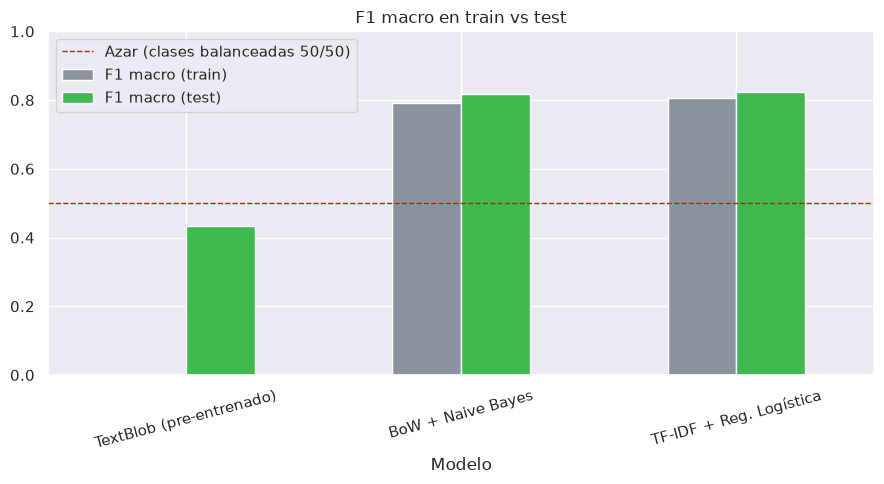

In [7]:
comparacion = pd.DataFrame({
    "Modelo": ["TextBlob (pre-entrenado)", "BoW + Naive Bayes", "TF-IDF + Reg. Logística"],
    "Accuracy (test)": [acc_textblob, acc_nb, acc_lr],
    "F1 macro (test)": [f1_textblob, f1_nb, f1_lr],
    "F1 macro (train)": [np.nan, f1_nb_train, f1_lr_train],   # TextBlob no se entrena: no tiene train
    "Gap train-test": [np.nan, f1_nb_train - f1_nb, f1_lr_train - f1_lr],
}).set_index("Modelo")

display(comparacion.style.format("{:.3f}", na_rep="—").background_gradient(cmap="Greens", subset=["Accuracy (test)", "F1 macro (test)"]))

comparacion[["F1 macro (train)", "F1 macro (test)"]].plot(
    kind="bar", figsize=(9, 5), color=["#8B949E", "#3FB950"])
plt.title("F1 macro en train vs test")
plt.axhline(0.5, ls="--", color="red", lw=1, label="Azar (clases balanceadas 50/50)")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

**Conclusión**

1. **Entrenar sobre el dominio gana por lejos:** 0.82 vs 0.59.
2. **Los dos modelos entrenados empatan** (0.8245 vs 0.8189 = ~2 tweets). El cuello de botella es **la representación, no el algoritmo**.
3. **Ninguno sobreajusta** — los dos gaps son negativos.
4. **Todos superan el azar (50%)**, pero TextBlob por poco.

*Referencia: el paper original de Sentiment140 (2009) reporta ~0.83 con Naive Bayes. Estamos en línea.*

## 8. ¿Y contra el test completo, con la clase neutral?

In [8]:
# Y que pasa si evaluamos contra el test COMPLETO (incluyendo la clase neutral, que
# ningun modelo puede predecir por no haberla visto en el train)?
X_test_full_bow = vec_bow.transform(X_test_full)
pred_nb_full = nb.predict(X_test_full_bow)
y_test_full = df_test["polarity"].map({0: -1, 2: 0, 4: 1})

print("BoW + Naive Bayes, evaluado contra el test COMPLETO (incluye neutral):")
print(classification_report(y_test_full, pred_nb_full, zero_division=0))


BoW + Naive Bayes, evaluado contra el test COMPLETO (incluye neutral):
              precision    recall  f1-score   support

          -1       0.67      0.81      0.73       177
           0       0.00      0.00      0.00       139
           1       0.53      0.82      0.65       182

    accuracy                           0.59       498
   macro avg       0.40      0.55      0.46       498
weighted avg       0.43      0.59      0.50       498



**Conclusión.** La clase neutral tiene **recall 0**: el modelo nunca puede predecirla porque no la vio nunca.

- Contra el test binario: **0.82** de accuracy.
- Contra el test completo: **0.59**.

→ **Es una limitación del dataset, no del modelo.** Ningún algoritmo lo resuelve — haría falta etiquetar datos a mano.

## 9. Guardado

In [9]:
joblib.dump(vec_bow, MODELS / "vec_bow.joblib")
joblib.dump(vec_tfidf, MODELS / "vec_tfidf.joblib")
joblib.dump(nb, MODELS / "nb.joblib")
joblib.dump(lr, MODELS / "lr.joblib")
joblib.dump({
    "textblob": {"accuracy": acc_textblob, "f1_macro": f1_textblob},
    "naive_bayes": {"accuracy_train": acc_nb_train, "f1_macro_train": f1_nb_train,
                    "accuracy_test": acc_nb, "f1_macro_test": f1_nb},
    "reg_logistica": {"accuracy_train": acc_lr_train, "f1_macro_train": f1_lr_train,
                      "accuracy_test": acc_lr, "f1_macro_test": f1_lr},
}, MODELS / "metricas.joblib")

print("Guardados en", MODELS.resolve())
print("  vec_bow.joblib | vec_tfidf.joblib | nb.joblib | lr.joblib | metricas.joblib")

Guardados en /home/matias/clases-diplomatura/tp3-nlp-tweets/models
  vec_bow.joblib | vec_tfidf.joblib | nb.joblib | lr.joblib | metricas.joblib
